# Stable Diffusion v1.5

## Setup

First, install the diffusers library.

In [2]:
%pip install -q diffusers

Import libraries.

In [1]:
from diffusers import StableDiffusionPipeline
import torch
import random
import numpy as np
import matplotlib.pyplot as plt

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Download Stable Diffusion.

In [2]:
# Download stable diffusion from huggingface
model_id = "stable-diffusion-v1-5/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)

# Move model to GPU
device = "cuda:0"
pipe = pipe.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Define helper functions.

In [3]:
# Set random seed for reproducability
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

Overwrite the generation function.

In [4]:
# Copyright 2025 The HuggingFace Team. All rights reserved.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.
import inspect
from typing import Any, Callable

import torch
from packaging import version
from transformers import CLIPImageProcessor, CLIPTextModel, CLIPTokenizer, CLIPVisionModelWithProjection

from diffusers.callbacks import MultiPipelineCallbacks, PipelineCallback
from diffusers.configuration_utils import FrozenDict
from diffusers.image_processor import PipelineImageInput, VaeImageProcessor
from diffusers.loaders import FromSingleFileMixin, IPAdapterMixin, StableDiffusionLoraLoaderMixin, TextualInversionLoaderMixin
from diffusers.models import AutoencoderKL, ImageProjection, UNet2DConditionModel
from diffusers.models.lora import adjust_lora_scale_text_encoder
from diffusers.schedulers import KarrasDiffusionSchedulers
from diffusers.utils import (
    USE_PEFT_BACKEND,
    deprecate,
    is_torch_xla_available,
    logging,
    replace_example_docstring,
    scale_lora_layers,
    unscale_lora_layers,
)
from diffusers.utils.torch_utils import randn_tensor
from diffusers.pipelines.pipeline_utils import DiffusionPipeline, StableDiffusionMixin
from diffusers.pipelines.stable_diffusion.pipeline_output import StableDiffusionPipelineOutput
from diffusers.pipelines.stable_diffusion.safety_checker import StableDiffusionSafetyChecker
from diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion import retrieve_timesteps

@torch.no_grad()
def generate(
    self,
    prompt: str | list[str] = None,
    height: int | None = None,
    width: int | None = None,
    num_inference_steps: int = 50,
    timesteps: list[int] = None,
    sigmas: list[float] = None,
    guidance_scale: float = 7.5,
    negative_prompt: str | list[str] | None = None,
    num_images_per_prompt: int | None = 1,
    eta: float = 0.0,
    generator: torch.Generator | list[torch.Generator] | None = None,
    latents: torch.Tensor | None = None,
    prompt_embeds: torch.Tensor | None = None,
    negative_prompt_embeds: torch.Tensor | None = None,
    ip_adapter_image: PipelineImageInput | None = None,
    ip_adapter_image_embeds: list[torch.Tensor] | None = None,
    output_type: str | None = "pil",
    return_dict: bool = True,
    cross_attention_kwargs: dict[str, Any] | None = None,
    guidance_rescale: float = 0.0,
    clip_skip: int | None = None,
    callback_on_step_end: Callable[[int, int], None] | PipelineCallback | MultiPipelineCallbacks | None = None,
    callback_on_step_end_tensor_inputs: list[str] = ["latents"],
    **kwargs,
):
    r"""
    The call function to the pipeline for generation.

    Args:
        prompt (`str` or `list[str]`, *optional*):
            The prompt or prompts to guide image generation. If not defined, you need to pass `prompt_embeds`.
        height (`int`, *optional*, defaults to `self.unet.config.sample_size * self.vae_scale_factor`):
            The height in pixels of the generated image.
        width (`int`, *optional*, defaults to `self.unet.config.sample_size * self.vae_scale_factor`):
            The width in pixels of the generated image.
        num_inference_steps (`int`, *optional*, defaults to 50):
            The number of denoising steps. More denoising steps usually lead to a higher quality image at the
            expense of slower inference.
        timesteps (`list[int]`, *optional*):
            Custom timesteps to use for the denoising process with schedulers which support a `timesteps` argument
            in their `set_timesteps` method. If not defined, the default behavior when `num_inference_steps` is
            passed will be used. Must be in descending order.
        sigmas (`list[float]`, *optional*):
            Custom sigmas to use for the denoising process with schedulers which support a `sigmas` argument in
            their `set_timesteps` method. If not defined, the default behavior when `num_inference_steps` is passed
            will be used.
        guidance_scale (`float`, *optional*, defaults to 7.5):
            A higher guidance scale value encourages the model to generate images closely linked to the text
            `prompt` at the expense of lower image quality. Guidance scale is enabled when `guidance_scale > 1`.
        negative_prompt (`str` or `list[str]`, *optional*):
            The prompt or prompts to guide what to not include in image generation. If not defined, you need to
            pass `negative_prompt_embeds` instead. Ignored when not using guidance (`guidance_scale < 1`).
        num_images_per_prompt (`int`, *optional*, defaults to 1):
            The number of images to generate per prompt.
        eta (`float`, *optional*, defaults to 0.0):
            Corresponds to parameter eta (η) from the [DDIM](https://huggingface.co/papers/2010.02502) paper. Only
            applies to the [`~schedulers.DDIMScheduler`], and is ignored in other schedulers.
        generator (`torch.Generator` or `list[torch.Generator]`, *optional*):
            A [`torch.Generator`](https://pytorch.org/docs/stable/generated/torch.Generator.html) to make
            generation deterministic.
        latents (`torch.Tensor`, *optional*):
            Pre-generated noisy latents sampled from a Gaussian distribution, to be used as inputs for image
            generation. Can be used to tweak the same generation with different prompts. If not provided, a latents
            tensor is generated by sampling using the supplied random `generator`.
        prompt_embeds (`torch.Tensor`, *optional*):
            Pre-generated text embeddings. Can be used to easily tweak text inputs (prompt weighting). If not
            provided, text embeddings are generated from the `prompt` input argument.
        negative_prompt_embeds (`torch.Tensor`, *optional*):
            Pre-generated negative text embeddings. Can be used to easily tweak text inputs (prompt weighting). If
            not provided, `negative_prompt_embeds` are generated from the `negative_prompt` input argument.
        ip_adapter_image: (`PipelineImageInput`, *optional*): Optional image input to work with IP Adapters.
        ip_adapter_image_embeds (`list[torch.Tensor]`, *optional*):
            Pre-generated image embeddings for IP-Adapter. It should be a list of length same as number of
            IP-adapters. Each element should be a tensor of shape `(batch_size, num_images, emb_dim)`. It should
            contain the negative image embedding if `do_classifier_free_guidance` is set to `True`. If not
            provided, embeddings are computed from the `ip_adapter_image` input argument.
        output_type (`str`, *optional*, defaults to `"pil"`):
            The output format of the generated image. Choose between `PIL.Image` or `np.array`.
        return_dict (`bool`, *optional*, defaults to `True`):
            Whether or not to return a [`~pipelines.stable_diffusion.StableDiffusionPipelineOutput`] instead of a
            plain tuple.
        cross_attention_kwargs (`dict`, *optional*):
            A kwargs dictionary that if specified is passed along to the [`AttentionProcessor`] as defined in
            [`self.processor`](https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/attention_processor.py).
        guidance_rescale (`float`, *optional*, defaults to 0.0):
            Guidance rescale factor from [Common Diffusion Noise Schedules and Sample Steps are
            Flawed](https://huggingface.co/papers/2305.08891). Guidance rescale factor should fix overexposure when
            using zero terminal SNR.
        clip_skip (`int`, *optional*):
            Number of layers to be skipped from CLIP while computing the prompt embeddings. A value of 1 means that
            the output of the pre-final layer will be used for computing the prompt embeddings.
        callback_on_step_end (`Callable`, `PipelineCallback`, `MultiPipelineCallbacks`, *optional*):
            A function or a subclass of `PipelineCallback` or `MultiPipelineCallbacks` that is called at the end of
            each denoising step during the inference. with the following arguments: `callback_on_step_end(self:
            DiffusionPipeline, step: int, timestep: int, callback_kwargs: Dict)`. `callback_kwargs` will include a
            list of all tensors as specified by `callback_on_step_end_tensor_inputs`.
        callback_on_step_end_tensor_inputs (`list`, *optional*):
            The list of tensor inputs for the `callback_on_step_end` function. The tensors specified in the list
            will be passed as `callback_kwargs` argument. You will only be able to include variables listed in the
            `._callback_tensor_inputs` attribute of your pipeline class.

    Examples:

    Returns:
        [`~pipelines.stable_diffusion.StableDiffusionPipelineOutput`] or `tuple`:
            If `return_dict` is `True`, [`~pipelines.stable_diffusion.StableDiffusionPipelineOutput`] is returned,
            otherwise a `tuple` is returned where the first element is a list with the generated images and the
            second element is a list of `bool`s indicating whether the corresponding generated image contains
            "not-safe-for-work" (nsfw) content.
    """

    callback = kwargs.pop("callback", None)
    callback_steps = kwargs.pop("callback_steps", None)

    if callback is not None:
        deprecate(
            "callback",
            "1.0.0",
            "Passing `callback` as an input argument to `__call__` is deprecated, consider using `callback_on_step_end`",
        )
    if callback_steps is not None:
        deprecate(
            "callback_steps",
            "1.0.0",
            "Passing `callback_steps` as an input argument to `__call__` is deprecated, consider using `callback_on_step_end`",
        )

    if isinstance(callback_on_step_end, (PipelineCallback, MultiPipelineCallbacks)):
        callback_on_step_end_tensor_inputs = callback_on_step_end.tensor_inputs

    # 0. Default height and width to unet
    if not height or not width:
        height = (
            self.unet.config.sample_size
            if self._is_unet_config_sample_size_int
            else self.unet.config.sample_size[0]
        )
        width = (
            self.unet.config.sample_size
            if self._is_unet_config_sample_size_int
            else self.unet.config.sample_size[1]
        )
        height, width = height * self.vae_scale_factor, width * self.vae_scale_factor
    # to deal with lora scaling and other possible forward hooks

    # 1. Check inputs. Raise error if not correct
    self.check_inputs(
        prompt,
        height,
        width,
        callback_steps,
        negative_prompt,
        prompt_embeds,
        negative_prompt_embeds,
        ip_adapter_image,
        ip_adapter_image_embeds,
        callback_on_step_end_tensor_inputs,
    )

    self._guidance_scale = guidance_scale
    self._guidance_rescale = guidance_rescale
    self._clip_skip = clip_skip
    self._cross_attention_kwargs = cross_attention_kwargs
    self._interrupt = False

    # 2. Define call parameters
    if prompt is not None and isinstance(prompt, str):
        batch_size = 1
    elif prompt is not None and isinstance(prompt, list):
        batch_size = len(prompt)
    else:
        batch_size = prompt_embeds.shape[0]

    device = self._execution_device

    # 3. Encode input prompt
    lora_scale = (
        self.cross_attention_kwargs.get("scale", None) if self.cross_attention_kwargs is not None else None
    )

    prompt_embeds, negative_prompt_embeds = self.encode_prompt(
        prompt,
        device,
        num_images_per_prompt,
        self.do_classifier_free_guidance,
        negative_prompt,
        prompt_embeds=prompt_embeds,
        negative_prompt_embeds=negative_prompt_embeds,
        lora_scale=lora_scale,
        clip_skip=self.clip_skip,
    )

    # For classifier free guidance, we need to do two forward passes.
    # Here we concatenate the unconditional and text embeddings into a single batch
    # to avoid doing two forward passes
    if self.do_classifier_free_guidance:
        prompt_embeds = torch.cat([negative_prompt_embeds, prompt_embeds])

    if ip_adapter_image is not None or ip_adapter_image_embeds is not None:
        image_embeds = self.prepare_ip_adapter_image_embeds(
            ip_adapter_image,
            ip_adapter_image_embeds,
            device,
            batch_size * num_images_per_prompt,
            self.do_classifier_free_guidance,
        )

    # 4. Prepare timesteps
    timestep_device = device
    timesteps, num_inference_steps = retrieve_timesteps(
        self.scheduler, num_inference_steps, timestep_device, timesteps, sigmas
    )

    # 5. Prepare latent variables
    num_channels_latents = self.unet.config.in_channels
    latents = self.prepare_latents(
        batch_size * num_images_per_prompt,
        num_channels_latents,
        height,
        width,
        prompt_embeds.dtype,
        device,
        generator,
        latents,
    )

    # 6. Prepare extra step kwargs. TODO: Logic should ideally just be moved out of the pipeline
    extra_step_kwargs = self.prepare_extra_step_kwargs(generator, eta)

    # 6.1 Add image embeds for IP-Adapter
    added_cond_kwargs = (
        {"image_embeds": image_embeds}
        if (ip_adapter_image is not None or ip_adapter_image_embeds is not None)
        else None
    )

    # 6.2 Optionally get Guidance Scale Embedding
    timestep_cond = None
    if self.unet.config.time_cond_proj_dim is not None:
        guidance_scale_tensor = torch.tensor(self.guidance_scale - 1).repeat(batch_size * num_images_per_prompt)
        timestep_cond = self.get_guidance_scale_embedding(
            guidance_scale_tensor, embedding_dim=self.unet.config.time_cond_proj_dim
        ).to(device=device, dtype=latents.dtype)

    # 7. Denoising loop
    num_warmup_steps = len(timesteps) - num_inference_steps * self.scheduler.order
    self._num_timesteps = len(timesteps)
    with self.progress_bar(total=num_inference_steps) as progress_bar:
        for i, t in enumerate(timesteps):
            if self.interrupt:
                continue

            # expand the latents if we are doing classifier free guidance
            latent_model_input = torch.cat([latents] * 2) if self.do_classifier_free_guidance else latents
            if hasattr(self.scheduler, "scale_model_input"):
                latent_model_input = self.scheduler.scale_model_input(latent_model_input, t)

            # predict the noise residual
            noise_pred = self.unet(
                latent_model_input,
                t,
                encoder_hidden_states=prompt_embeds,
                timestep_cond=timestep_cond,
                cross_attention_kwargs=self.cross_attention_kwargs,
                added_cond_kwargs=added_cond_kwargs,
                return_dict=False,
            )[0]

            # perform guidance
            if self.do_classifier_free_guidance:
                noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
                noise_pred = noise_pred_uncond + self.guidance_scale * (noise_pred_text - noise_pred_uncond)

            # compute the previous noisy sample x_t -> x_t-1
            latents = self.scheduler.step(noise_pred, t, latents, **extra_step_kwargs, return_dict=False)[0]

            if callback_on_step_end is not None:
                callback_kwargs = {}
                for k in callback_on_step_end_tensor_inputs:
                    callback_kwargs[k] = locals()[k]
                callback_outputs = callback_on_step_end(self, i, t, callback_kwargs)

                latents = callback_outputs.pop("latents", latents)
                prompt_embeds = callback_outputs.pop("prompt_embeds", prompt_embeds)
                negative_prompt_embeds = callback_outputs.pop("negative_prompt_embeds", negative_prompt_embeds)

            # call the callback, if provided
            if i == len(timesteps) - 1 or ((i + 1) > num_warmup_steps and (i + 1) % self.scheduler.order == 0):
                progress_bar.update()
                if callback is not None and i % callback_steps == 0:
                    step_idx = i // getattr(self.scheduler, "order", 1)
                    callback(step_idx, t, latents)

    if not output_type == "latent":
        image = self.vae.decode(latents / self.vae.config.scaling_factor, return_dict=False, generator=generator)[
            0
        ]
        image, has_nsfw_concept = self.run_safety_checker(image, device, prompt_embeds.dtype)
    else:
        image = latents
        has_nsfw_concept = None

    if has_nsfw_concept is None:
        do_denormalize = [True] * image.shape[0]
    else:
        do_denormalize = [not has_nsfw for has_nsfw in has_nsfw_concept]

    image = self.image_processor.postprocess(image, output_type=output_type, do_denormalize=do_denormalize)

    # Offload all models
    self.maybe_free_model_hooks()

    if not return_dict:
        return (image, has_nsfw_concept)

    return StableDiffusionPipelineOutput(images=image, nsfw_content_detected=has_nsfw_concept)

pipe.generate = generate.__get__(pipe)


Generate an example image.

  0%|          | 0/50 [00:00<?, ?it/s]

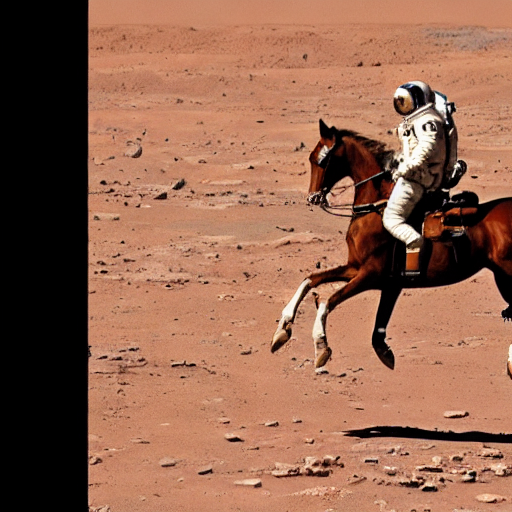

In [5]:
set_seed(0)
prompt = "a photo of an astronaut riding a horse on mars"
image = pipe.generate(prompt).images[0]
image